### MESA Comparison with our Profile

In [6]:
import os
import re
import math
import glob
import random
import datetime as dt

import numpy as np
import pandas as pd
import scipy
from scipy import io, interpolate
from scipy.optimize import curve_fit, brentq
from scipy.signal import convolve2d
from scipy.ndimage import median_filter
from scipy.interpolate import RegularGridInterpolator, PchipInterpolator
import numpy.lib.recfunctions

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Patch
import matplotlib as mpl

from PIL import Image
from astropy.io import ascii

%matplotlib inline

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "axes.linewidth": 2.0,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.major.size": 8,
    "xtick.major.width": 2,
    "xtick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.major.size": 8,
    "ytick.major.width": 2,
    "ytick.minor.size": 4,
    "ytick.minor.width": 1.5,
    "ytick.right": True,
    "lines.linewidth": 2,
    "legend.fontsize": 10,
    "legend.frameon": False,
})

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from constants import *
from zams_eos import *
from zams_opacity import *
from zams_energygeneration import *
from zams_gradients import *
from zams_structure_equations import *
from zams_initialboundaries import *
from zams_integrate import *

ours = pd.read_csv('/Users/kmanj/Desktop/Stellar Structure Calculation/Github Files/notebooks/stellar_structure_table.csv')
mesa  = pd.read_csv('/Users/kmanj/mesa_work/mesa_profile.csv')

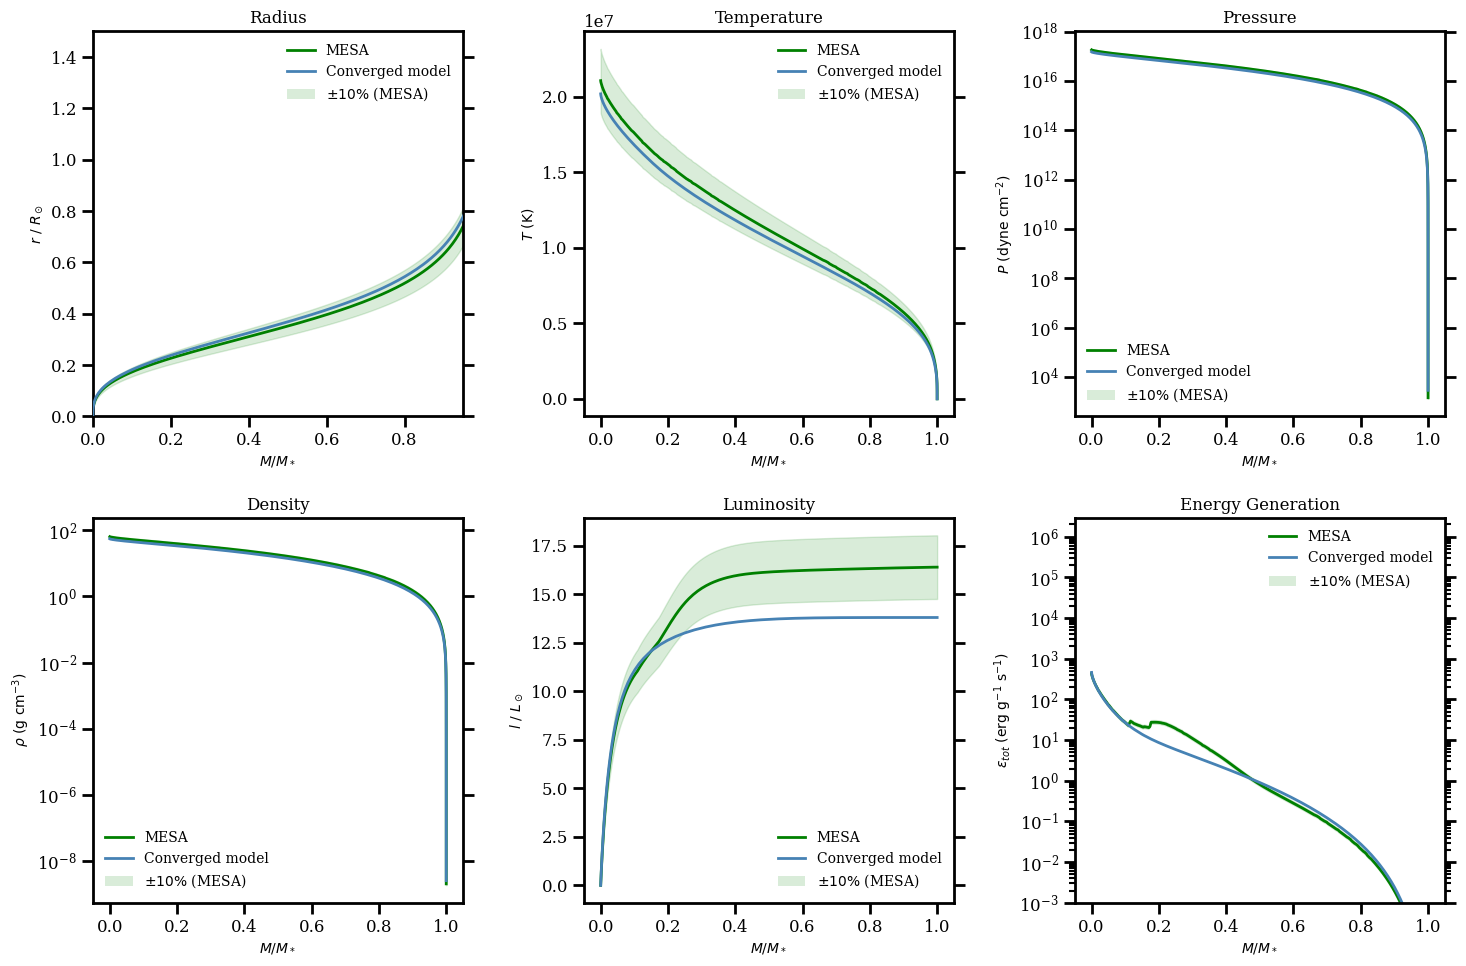

In [3]:
M_sun = 1.989e33
R_sun = 6.957e10
L_sun = 3.828e33

q_ours = ours['m'] / 2.0
q_mesa  = mesa['mass'] / 2.0 

band_patch = Patch(facecolor='green', alpha=0.15, label=r'$\pm 10\%$ (MESA)')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

def safe_semilogy(ax, x, y, **kwargs):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    mask = np.isfinite(y) & (y > 0)
    if mask.sum() > 0:
        ax.semilogy(x[mask], y[mask], **kwargs)

def safe_fill_band(ax, x, y, frac=0.10, **kwargs):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    ylo = (1 - frac) * y
    yhi = (1 + frac) * y
    mask = np.isfinite(x) & np.isfinite(ylo) & np.isfinite(yhi) & (yhi > 0)
    if mask.sum() > 0:
        ax.fill_between(x[mask], ylo[mask], yhi[mask], **kwargs)

# Radius
safe_fill_band(axes[0], q_mesa, mesa['r'], frac=0.10, color='green', alpha=0.15, zorder=1)
axes[0].plot(q_mesa,  mesa['r'],              label='MESA',            color='green', zorder=2)
axes[0].plot(q_ours, ours['r'],     label='Converged model', color='steelblue', zorder=3)
axes[0].set_xlabel(r'$M/M_*$')
axes[0].set_ylabel(r'$r \ / \ R_\odot$')
axes[0].set_title('Radius')
handles, labels = axes[0].get_legend_handles_labels()
handles.append(band_patch)
labels.append(r'$\pm 10\%$ (MESA)')
axes[0].legend(handles, labels)
axes[0].set_ylim(0, 1.5)
axes[0].set_xlim(0, 0.95)

# Temperature
safe_fill_band(axes[1], q_mesa, mesa['T'], frac=0.10, color='green', alpha=0.15, zorder=1)
axes[1].plot(q_mesa,  mesa['T'],   label='MESA',            color='green', zorder=2)
axes[1].plot(q_ours, ours['T'],  label='Converged model', color='steelblue', zorder=3)
axes[1].set_xlabel(r'$M/M_*$')
axes[1].set_ylabel(r'$T \ \mathrm{(K)}$')
axes[1].set_title('Temperature')
handles, labels = axes[1].get_legend_handles_labels()
handles.append(band_patch)
labels.append(r'$\pm 10\%$ (MESA)')
axes[1].legend(handles, labels)

# Pressure
safe_fill_band(axes[2], q_mesa, mesa['P'], frac=0.10, color='green', alpha=0.15, zorder=1)
safe_semilogy(axes[2], q_mesa,  mesa['P'],    label='MESA',            color='green')
safe_semilogy(axes[2], q_ours, ours['P'],   label='Converged model', color='steelblue')
axes[2].set_xlabel(r'$M/M_*$')
axes[2].set_ylabel(r'$P \ \mathrm{(dyne \ cm^{-2})}$')
axes[2].set_title('Pressure')
handles, labels = axes[2].get_legend_handles_labels()
handles.append(band_patch)
labels.append(r'$\pm 10\%$ (MESA)')
axes[2].legend(handles, labels)

# Density
safe_fill_band(axes[3], q_mesa, mesa['rho'], frac=0.10, color='green', alpha=0.15, zorder=1)
safe_semilogy(axes[3], q_mesa,  mesa['rho'],  label='MESA',            color='green')
safe_semilogy(axes[3], q_ours, ours['rho'], label='Converged model', color='steelblue')
axes[3].set_xlabel(r'$M/M_*$')
axes[3].set_ylabel(r'$\rho \ \mathrm{(g \ cm^{-3})}$')
axes[3].set_title('Density')
handles, labels = axes[3].get_legend_handles_labels()
handles.append(band_patch)
labels.append(r'$\pm 10\%$ (MESA)')
axes[3].legend(handles, labels)

# Luminosity
safe_fill_band(axes[4], q_mesa, mesa['l'], frac=0.10, color='green', alpha=0.15, zorder=1)
axes[4].plot(q_mesa,  mesa['l'],              label='MESA',            color='green', zorder=2)
axes[4].plot(q_ours, ours['l'],     label='Converged model', color='steelblue', zorder=3)
axes[4].set_xlabel(r'$M/M_*$')
axes[4].set_ylabel(r'$l \ / \ L_\odot$')
axes[4].set_title('Luminosity')
handles, labels = axes[4].get_legend_handles_labels()
handles.append(band_patch)
labels.append(r'$\pm 10\%$ (MESA)')
axes[4].legend(handles, labels)

# Energy generation
safe_fill_band(axes[5], q_mesa, mesa['eps'], frac=0.10, color='green', alpha=0.15, zorder=1)
safe_semilogy(axes[5], q_mesa,  mesa['eps'],  label='MESA',            color='green')
safe_semilogy(axes[5], q_ours, ours['eps'], label='Converged model', color='steelblue')
axes[5].set_xlabel(r'$M/M_*$')
axes[5].set_ylabel(r'$\epsilon_{tot} \ \mathrm{(erg \ g^{-1} \ s^{-1})}$')
axes[5].set_title('Energy Generation')
handles, labels = axes[5].get_legend_handles_labels()
handles.append(band_patch)
labels.append(r'$\pm 10\%$ (MESA)')
axes[5].legend(handles, labels)
axes[5].set_ylim(bottom=1e-3)
plt.tight_layout()
#plt.savefig('mesa_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [4]:
G = 6.67430e-8
sigma_sb = 5.670374419e-5
M_sun = 1.989e33
R_sun = 6.957e10
L_sun = 3.828e33

# stellar mass
M_star = 2.0 * M_sun

R_star = ours['r'].iloc[-1]
L_star = ours['l'].iloc[-1]

# surface gravity
g_star = G * M_star / R_star**2

# effective temperature
T_eff = (L_star / (4*np.pi*R_star**2 * sigma_sb))**0.25

# MESA values
R_mesa = mesa['r'].iloc[-1] 
L_mesa = mesa['l'].iloc[-1] 
g_mesa = G * M_star / R_mesa**2
T_eff_mesa = (L_mesa / (4*np.pi*R_mesa**2 * sigma_sb))**0.25

# percent differences
def pct(a, b):
    return abs((a - b) / b) * 100

print("R:", pct(R_star, R_mesa))
print("L:", pct(L_star, L_mesa))
print("g:", pct(g_star, g_mesa))
print("Teff:", pct(T_eff, T_eff_mesa))

R: 4.21754963880089
L: 15.82063200995666
g: 7.929970066703369
Teff: 6.172318213760091


In [5]:
# stellar mass
M_star = 2.0 * M_sun

# surface values (last point)
R_star = ours[ours['r'] > 0]['r'].iloc[-1] * R_sun
L_star = ours[ours['l'] > 0]['l'].iloc[-1] * L_sun
T_surface = ours['T'].iloc[-1]
P_surface = ours['P'].iloc[-1]
rho_surface = ours['rho'].iloc[-1]

# central values (first point)
T_c = ours['T'].iloc[0]
P_c = ours['P'].iloc[0]
rho_c = ours['rho'].iloc[0]
eps_c = ours['eps'].iloc[0]

# derived quantities
g_star = G * M_star / R_star**2
T_eff = (L_star / (4 * np.pi * R_star**2 * sigma_sb))**0.25

# print nicely
print("GLOBAL STELLAR PROPERTIES")
print(f"Mass:           {M_star/M_sun:.2f} M_sun")
print(f"Radius:         {R_star/R_sun:.4f} R_sun")
print(f"Luminosity:     {L_star/L_sun:.4f} L_sun")
print(f"Teff:           {T_eff:.2f} K")
print(f"log g:          {np.log10(g_star):.4f}")

print("\nCENTRAL CONDITIONS")
print(f"T_c:            {T_c:.3e} K")
print(f"P_c:            {P_c:.3e} dyne/cm^2")
print(f"rho_c:          {rho_c:.3e} g/cm^3")
print(f"epsilon_c:      {eps_c:.3e} erg/g/s")

print("\nSURFACE CONDITIONS")
print(f"T_surface:      {T_surface:.3e} K")
print(f"P_surface:      {P_surface:.3e} dyne/cm^2")
print(f"rho_surface:    {rho_surface:.3e} g/cm^3")

GLOBAL STELLAR PROPERTIES
Mass:           2.00 M_sun
Radius:         1.7126 R_sun
Luminosity:     13.8097 L_sun
Teff:           8502.48 K
log g:          4.2719

CENTRAL CONDITIONS
T_c:            2.018e+07 K
P_c:            1.500e+17 dyne/cm^2
rho_c:          5.548e+01 g/cm^3
epsilon_c:      4.609e+02 erg/g/s

SURFACE CONDITIONS
T_surface:      8.502e+03 K
P_surface:      2.872e+03 dyne/cm^2
rho_surface:    2.516e-09 g/cm^3
